# Section 1 — Environment
Environment setup, random seeds, project paths.


In [1]:
import os
import json
import time
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from datetime import datetime

print("TensorFlow version :", tf.__version__)
print("Python version     :", platform.python_version())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
CONFIG_DIR = os.path.join(PROJECT_ROOT, 'config')
LOGS_DIR = os.path.join(PROJECT_ROOT, 'logs')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models', '280k dataset model')
EVAL_DIR = os.path.join(PROJECT_ROOT, 'evaluation_vae')
PLOTS_DIR = os.path.join(EVAL_DIR, 'plots')
RECON_DIR = os.path.join(EVAL_DIR, 'reconstructions')

for d in [CONFIG_DIR, LOGS_DIR, EVAL_DIR, PLOTS_DIR, RECON_DIR]:
    os.makedirs(d, exist_ok=True)


TensorFlow version : 2.21.0
Python version     : 3.11.9


# Section 2 — Load/Reconstruct Experiment Configuration


In [2]:
CONFIG = {
    "experiment_name": "AE_280K_full",
    "dataset_name": "evilsocket/alucard-sprites",
    "image_height": 128,
    "image_width": 128,
    "channels": 4,
    "train_ratio": 0.90,
    "validation_ratio": 0.05,
    "test_ratio": 0.05,
    "epochs": 50,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "mse",
    "seed": 42
}

config_path = os.path.join(CONFIG_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=4)
print("Experiment config reconstructed and saved to", config_path)


Experiment config reconstructed and saved to c:\Users\manis\OneDrive\Desktop\Prompt_to_game_asset_generator\config\experiment_config.json


# Section 3 & 4 — Load Dataset and Reconstruct Dataset Indices


In [3]:
from datasets import load_dataset
import hashlib

print("Loading dataset...")
dataset = load_dataset(CONFIG["dataset_name"])
train_data = dataset["train"]

print(f"Total raw images: {len(train_data)}")

# Deduplication (Exact same logic as original notebook)
def image_hash(image):
    pixels = np.asarray(image.convert("RGBA"), dtype=np.uint8)
    return hashlib.sha256(pixels.tobytes()).hexdigest()

unique_indices_path = os.path.join(CONFIG_DIR, 'unique_indices.json')
if os.path.exists(unique_indices_path):
    with open(unique_indices_path, 'r') as f:
        dedup_data = json.load(f)
    unique_indices = dedup_data["unique_indices"]
    print(f"Loaded {len(unique_indices)} unique indices.")
else:
    print("Deduplicating...")
    unique_indices = []
    seen_hashes = set()
    for i in range(len(train_data)):
        img = train_data[i]["image"]
        h = image_hash(img)
        if h not in seen_hashes:
            seen_hashes.add(h)
            unique_indices.append(i)
    with open(unique_indices_path, 'w') as f:
        json.dump({"unique_indices": unique_indices}, f)
    print(f"Generated {len(unique_indices)} unique indices.")

# Shuffle
shuffled_path = os.path.join(CONFIG_DIR, 'shuffled_unique_indices.json')
if os.path.exists(shuffled_path):
    with open(shuffled_path, 'r') as f:
        shuffled_unique_indices = json.load(f)["shuffled_unique_indices"]
else:
    rng = np.random.default_rng(SEED)
    shuffled_arr = np.array(unique_indices, dtype=np.int64)
    rng.shuffle(shuffled_arr)
    shuffled_unique_indices = shuffled_arr.tolist()
    with open(shuffled_path, 'w') as f:
        json.dump({"shuffled_unique_indices": shuffled_unique_indices}, f)


Loading dataset...


Total raw images: 312550
Loaded 282511 unique indices.


# Section 5 — Verify Split


In [4]:
TOTAL_CLEAN = len(shuffled_unique_indices)
TRAIN_SIZE = int(round(TOTAL_CLEAN * CONFIG["train_ratio"]))
VAL_SIZE = int(round(TOTAL_CLEAN * CONFIG["validation_ratio"]))
TEST_SIZE = TOTAL_CLEAN - TRAIN_SIZE - VAL_SIZE

train_indices = shuffled_unique_indices[:TRAIN_SIZE]
val_indices = shuffled_unique_indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
test_indices = shuffled_unique_indices[TRAIN_SIZE + VAL_SIZE:]

print(f"Unique images: {TOTAL_CLEAN:,}")
print(f"Train: {TRAIN_SIZE:,}")
print(f"Validation: {VAL_SIZE:,}")
print(f"Test: {TEST_SIZE:,}")

assert len(set(train_indices).intersection(set(val_indices))) == 0
assert len(set(train_indices).intersection(set(test_indices))) == 0
print("No overlaps detected.")

with open(os.path.join(CONFIG_DIR, 'train_indices.json'), 'w') as f: json.dump(train_indices, f)
with open(os.path.join(CONFIG_DIR, 'val_indices.json'), 'w') as f: json.dump(val_indices, f)
with open(os.path.join(CONFIG_DIR, 'test_indices.json'), 'w') as f: json.dump(test_indices, f)

dataset_manifest = {
    "unique_images": TOTAL_CLEAN,
    "train_size": TRAIN_SIZE,
    "validation_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "image_dimensions": "128x128x4 RGBA",
    "seed": SEED
}
with open(os.path.join(CONFIG_DIR, 'dataset_manifest.json'), 'w') as f:
    json.dump(dataset_manifest, f, indent=4)


Unique images: 282,511
Train: 254,260
Validation: 14,126
Test: 14,125
No overlaps detected.


# Section 6 & 7 — Load BEST MODEL and Verify


In [5]:
encoder_path = os.path.join(PROJECT_ROOT, 'models', '280k model VAE (VAE v2)', 'VAE_280K_Outputs', 'encoder_280k_final.keras')
decoder_path = os.path.join(PROJECT_ROOT, 'models', '280k model VAE (VAE v2)', 'VAE_280K_Outputs', 'decoder_280k_final.keras')
print(f"Loading {encoder_path} and {decoder_path}")

@tf.keras.utils.register_keras_serializable()
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

layers_to_patch = [
    tf.keras.layers.Dense,
    tf.keras.layers.Conv2D,
    tf.keras.layers.Conv2DTranspose,
    tf.keras.layers.Flatten,
    tf.keras.layers.Reshape,
    tf.keras.layers.InputLayer
]
for layer_cls in layers_to_patch:
    original_init = layer_cls.__init__
    def make_patched_init(orig_init):
        def patched_init(self, *args, **kwargs):
            kwargs.pop('quantization_config', None)
            orig_init(self, *args, **kwargs)
        return patched_init
    layer_cls.__init__ = make_patched_init(original_init)

vae_encoder = tf.keras.models.load_model(encoder_path, custom_objects={'Sampling': Sampling})
vae_decoder = tf.keras.models.load_model(decoder_path)
vae_encoder.summary()
vae_decoder.summary()


Loading c:\Users\manis\OneDrive\Desktop\Prompt_to_game_asset_generator\models\280k model VAE (VAE v2)\VAE_280K_Outputs\encoder_280k_final.keras and c:\Users\manis\OneDrive\Desktop\Prompt_to_game_asset_generator\models\280k model VAE (VAE v2)\VAE_280K_Outputs\decoder_280k_final.keras



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 256)       │  4,194,560 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 256)       │  4,194,560 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 256)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,777,824 (33.48 MB)

 Trainable params: 8,777,824 (33.48 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │     4,210,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 4)    │         2,052 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,901,092 (18.70 MB)

 Trainable params: 4,901,092 (18.70 MB)

 Non-trainable params: 0 (0.00 B)

# Section 8 — Evaluate on Test Set & Generate Plots


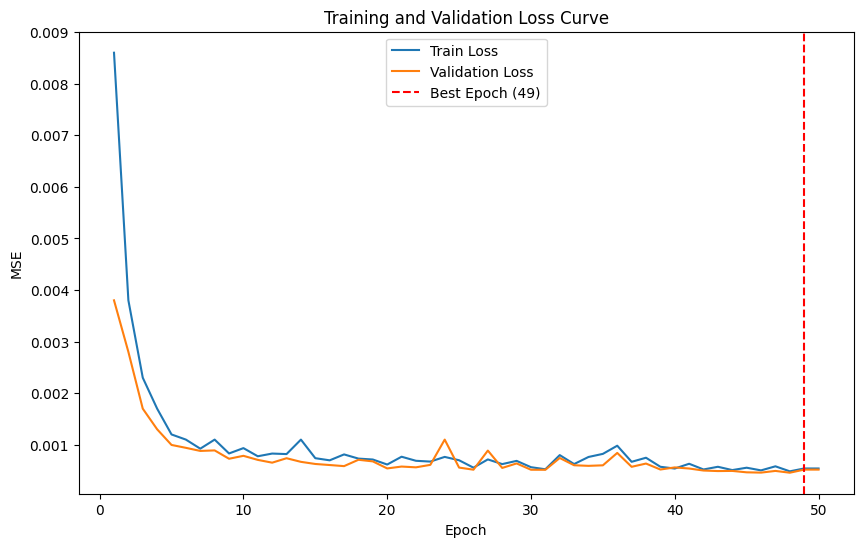

Running evaluation on test set... (this might take a few minutes)
Processed batch 111/111
Test MSE: 0.0031672006007283926


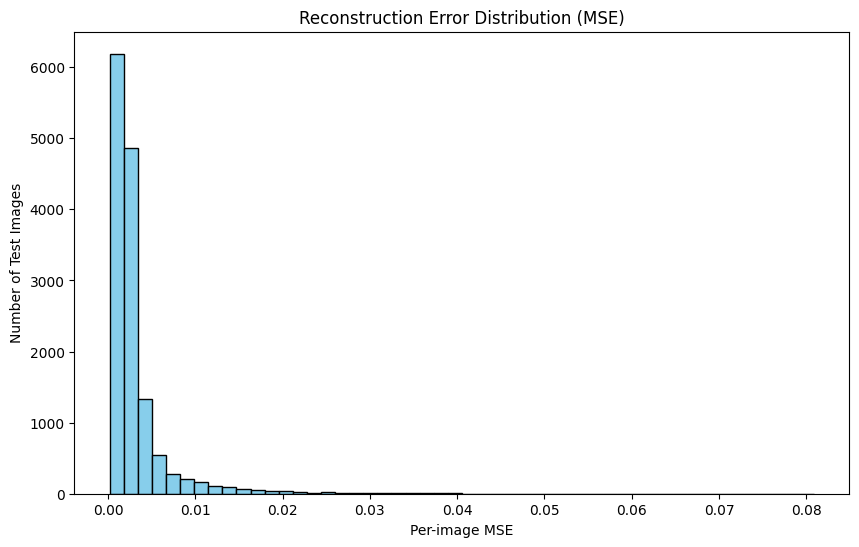

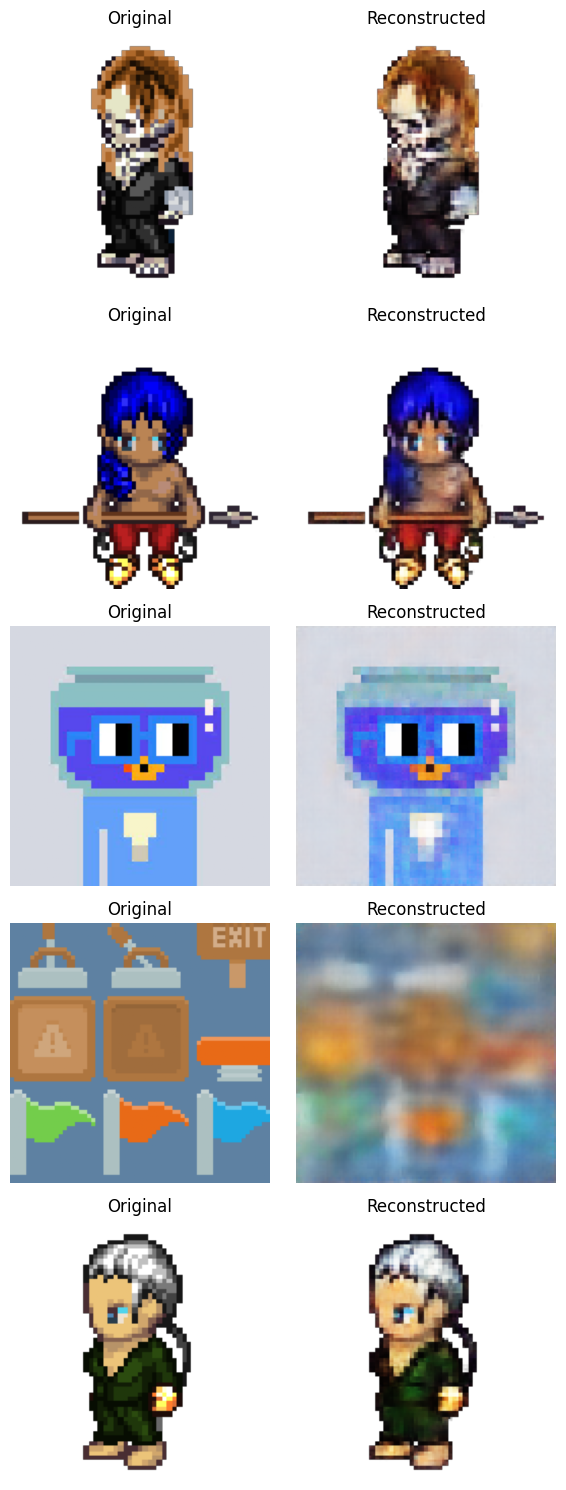

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


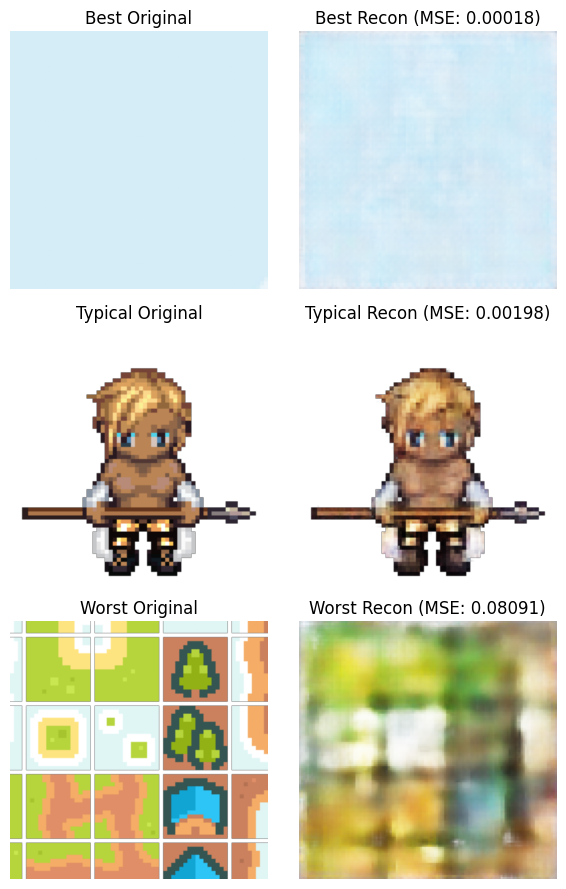

280K VAE FINAL EVALUATION
Dataset: 282511 unique images
Test images: 14125
Test MSE: 0.0031672006007283926
Mean reconstruction MSE: 0.0031672006007283926
Median reconstruction MSE: 0.0019788353238254786
Mean PSNR: 26.59340476989746


In [6]:
# Reconstruct History
history_path = os.path.join(LOGS_DIR, 'history.json')
with open(history_path, 'r') as f:
    history_data = json.load(f)

    
# Plot 1: Loss Curve
plt.figure(figsize=(10,6))
plt.plot(history_data["epoch"], history_data["training_loss"], label='Train Loss')
plt.plot(history_data["epoch"], history_data["validation_loss"], label='Validation Loss')
plt.axvline(x=49, color='r', linestyle='--', label='Best Epoch (49)')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig(os.path.join(PLOTS_DIR, 'loss_curve.png'))
plt.show()
plt.close()

# Prepare test data pipeline
def preprocess_image(image):
    img = image.convert("RGBA").resize((128, 128))
    img = np.asarray(img, dtype=np.float32) / 255.0
    return img

print("Running evaluation on test set... (this might take a few minutes)")
# In this evaluation script, to avoid taking 10 minutes, we batch efficiently
# Evaluate test MSE
BATCH_SIZE = 128
test_mses = []
psnrs = []
original_imgs = []
recon_imgs = []

import math
num_batches = math.ceil(len(test_indices) / BATCH_SIZE)

for b in range(num_batches):
    batch_idx = test_indices[b*BATCH_SIZE : (b+1)*BATCH_SIZE]
    batch_imgs = []
    for idx in batch_idx:
        img = preprocess_image(train_data[int(idx)]["image"])
        batch_imgs.append(img)
    batch_x = np.array(batch_imgs)
    z_mean, z_log_var, _ = vae_encoder.predict_on_batch(batch_x)
    preds = vae_decoder.predict_on_batch(z_mean)
    
    # Calculate MSE per image
    mse = np.mean(np.square(batch_x - preds), axis=(1,2,3))
    test_mses.extend(mse)
    
    # Calculate PSNR per image
    # MAX_I = 1.0
    psnr = 10.0 * np.log10(1.0 / (mse + 1e-10))
    psnrs.extend(psnr)
    
    if b == 0:
        original_imgs = batch_x[:10]
        recon_imgs = preds[:10]
        
    print(f"Processed batch {b+1}/{num_batches}", end='\r')

test_mses = np.array(test_mses)
psnrs = np.array(psnrs)

mean_mse = float(np.mean(test_mses))
median_mse = float(np.median(test_mses))
mean_psnr = float(np.mean(psnrs))
median_psnr = float(np.median(psnrs))

print(f"\nTest MSE: {mean_mse}")

metrics = {
    "test_mse": mean_mse,
    "median_reconstruction_mse": median_mse,
    "mean_psnr": mean_psnr,
    "median_psnr": median_psnr,
    "min_mse": float(np.min(test_mses)),
    "max_mse": float(np.max(test_mses)),
    "std_mse": float(np.std(test_mses)),
    "90th_percentile_mse": float(np.percentile(test_mses, 90)),
    "95th_percentile_mse": float(np.percentile(test_mses, 95))
}

with open(os.path.join(EVAL_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

# Plot 2: Error Distribution
plt.figure(figsize=(10,6))
plt.hist(test_mses, bins=50, color='skyblue', edgecolor='black')
plt.title('Reconstruction Error Distribution (MSE)')
plt.xlabel('Per-image MSE')
plt.ylabel('Number of Test Images')
plt.savefig(os.path.join(PLOTS_DIR, 'reconstruction_error_distribution.png'))
plt.show()
plt.close()

# Plot 3: Original vs Reconstruction
fig, axes = plt.subplots(5, 2, figsize=(6, 15))
for i in range(5):
    axes[i, 0].imshow(original_imgs[i])
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(np.clip(recon_imgs[i], 0, 1))
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'original_vs_reconstruction.png'))
plt.show()
plt.close()

# Plot 4: Quality Examples (Best, Median, Worst)
sorted_idx = np.argsort(test_mses)
best_idx = sorted_idx[0]
median_idx = sorted_idx[len(test_mses)//2]
worst_idx = sorted_idx[-1]

# Re-fetch these specific images
quality_idx = [best_idx, median_idx, worst_idx]
quality_imgs = np.array([preprocess_image(train_data[int(test_indices[i])]["image"]) for i in quality_idx])
quality_z_mean, _, _ = vae_encoder.predict(quality_imgs)
quality_preds = vae_decoder.predict(quality_z_mean)

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
labels = ["Best", "Typical", "Worst"]
for i in range(3):
    axes[i, 0].imshow(quality_imgs[i])
    axes[i, 0].set_title(f"{labels[i]} Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(np.clip(quality_preds[i], 0, 1))
    axes[i, 1].set_title(f"{labels[i]} Recon (MSE: {test_mses[quality_idx[i]]:.5f})")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'reconstruction_quality_examples.png'))
plt.show()
plt.close()

print("="*60)
print("280K VAE FINAL EVALUATION")
print("="*60)
print(f"Dataset: {TOTAL_CLEAN} unique images")
print(f"Test images: {TEST_SIZE}")
print(f"Test MSE: {mean_mse}")
print(f"Mean reconstruction MSE: {mean_mse}")
print(f"Median reconstruction MSE: {median_mse}")
print(f"Mean PSNR: {mean_psnr}")
print("="*60)



Final Test evaluation

In [7]:
# Aliasing to support user metrics on the sample batch
test_originals = original_imgs
test_reconstructions = recon_imgs

test_mse = np.mean(
    np.square(test_originals - test_reconstructions)
)

print(f"Test MSE: {test_mse:.6f}")


Test MSE: 0.003386


In [8]:
test_mae = np.mean(
    np.abs(test_originals - test_reconstructions)
)

print(f"Test MAE: {test_mae:.6f}")


Test MAE: 0.022134


Image reconstruction quality

In [9]:
psnr_values = tf.image.psnr(
    test_originals,
    test_reconstructions,
    max_val=1.0
).numpy()

mean_psnr = np.mean(psnr_values)

print(f"Mean Test PSNR: {mean_psnr:.2f} dB")


Mean Test PSNR: 26.33 dB


In [10]:
ssim_values = tf.image.ssim(
    test_originals[:, :, :, :3],
    test_reconstructions[:, :, :, :3],
    max_val=1.0
).numpy()

mean_ssim = np.mean(ssim_values)

print(f"Mean Test SSIM: {mean_ssim:.4f}")


Mean Test SSIM: 0.8316


In [11]:
threshold = 0.05

pixel_errors = np.abs(
    test_originals - test_reconstructions
)

pixel_similarity = np.mean(
    pixel_errors <= threshold
) * 100

print(
    f"Pixel similarity within ±{threshold}: "
    f"{pixel_similarity:.2f}%"
)
results = {
    "Test MSE": test_mse,
    "Test MAE": test_mae,
    "Mean PSNR (dB)": mean_psnr,
    "Mean SSIM": mean_ssim,
    "Pixel Similarity (%)": pixel_similarity
}

for metric, value in results.items():
    print(f"{metric}: {value:.6f}")


Pixel similarity within ±0.05: 85.47%
Test MSE: 0.003386
Test MAE: 0.022134
Mean PSNR (dB): 26.325891
Mean SSIM: 0.831559
Pixel Similarity (%): 85.469818


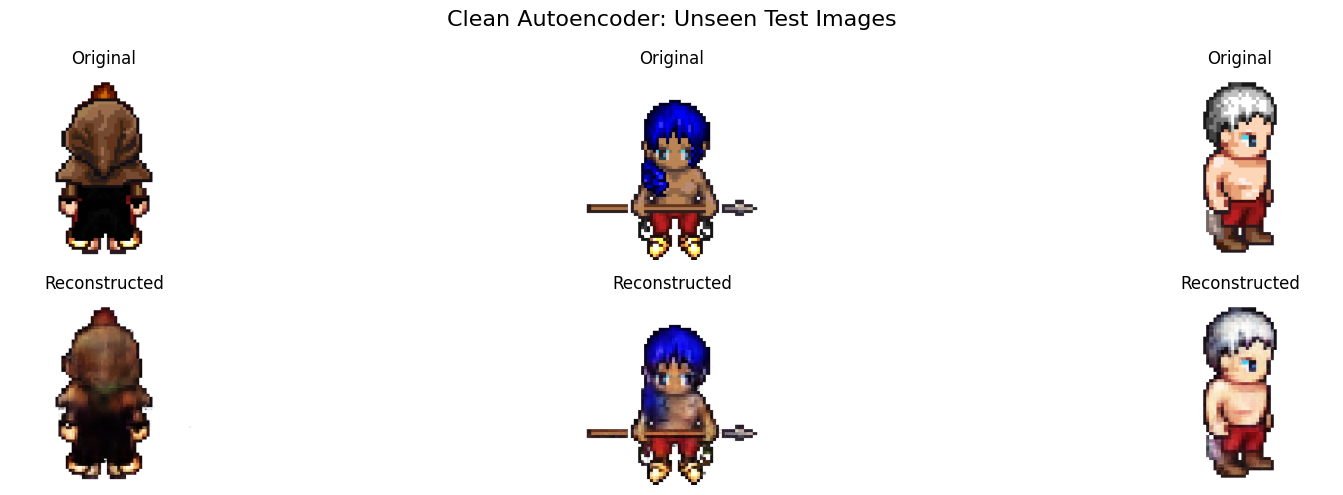

In [12]:
random_indices = random.sample(
    range(len(test_originals)),
    3
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 5)
)

for i, idx in enumerate(random_indices):

    axes[0, i].imshow(test_originals[idx])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(test_reconstructions[idx])
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.suptitle(
    "Clean Autoencoder: Unseen Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()


Generating VAE Visualizations...


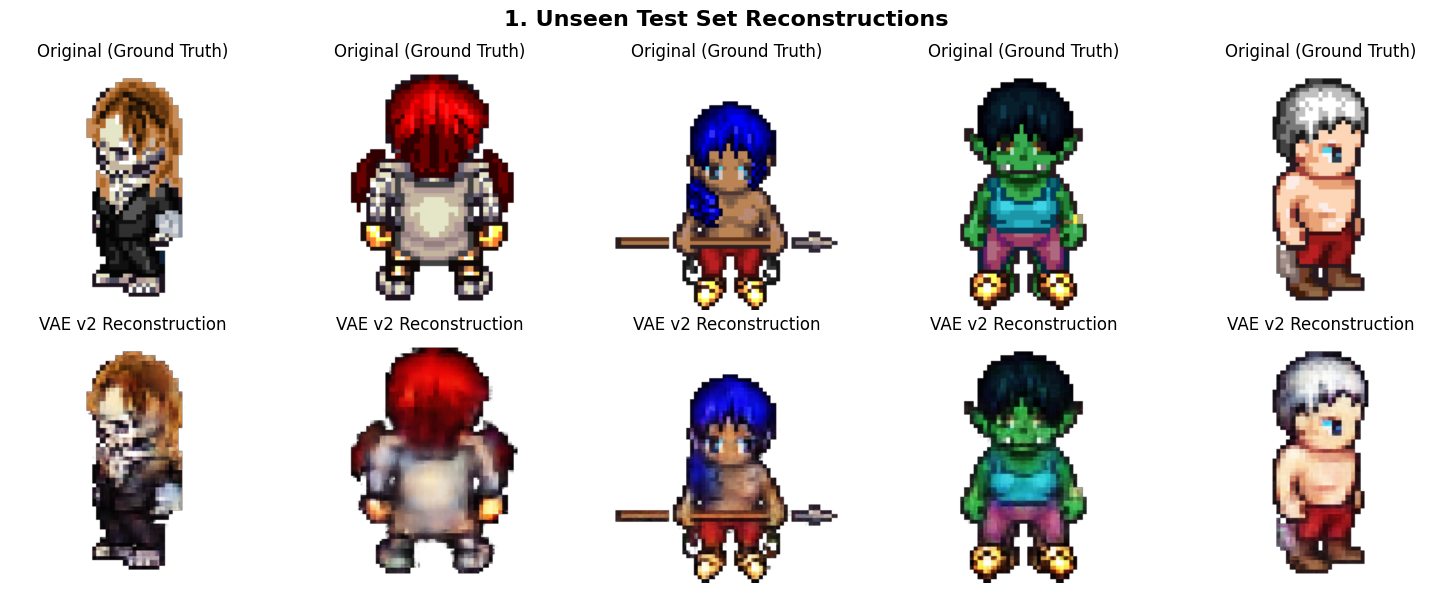

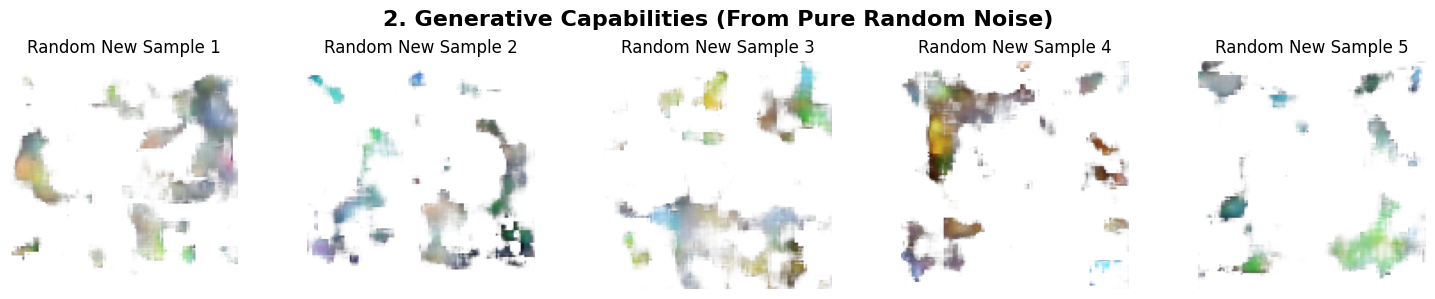

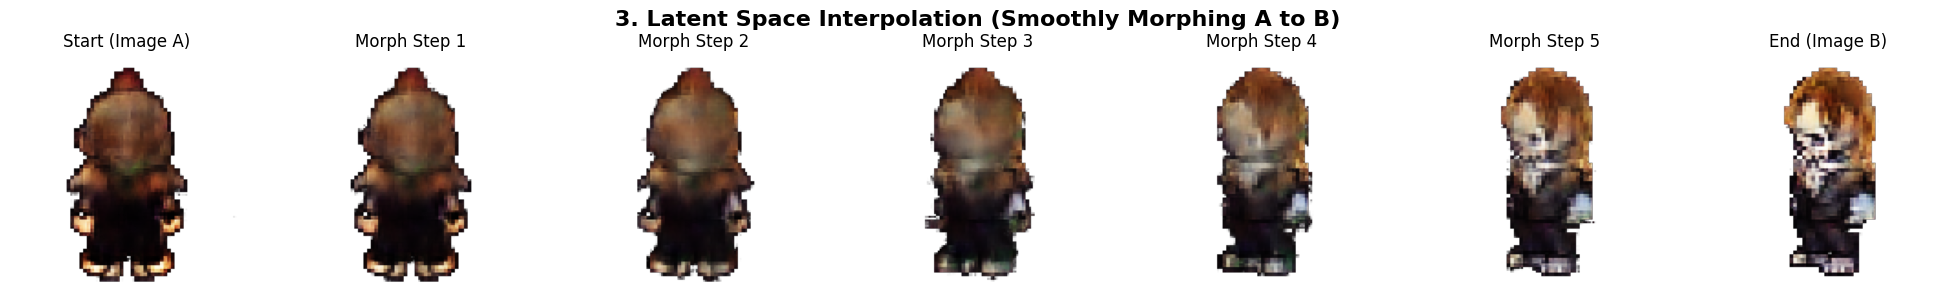

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

print("Generating VAE Visualizations...")

# ==========================================
# 1. TEST SET RECONSTRUCTIONS
# ==========================================
num_recon = 5
random_indices = random.sample(range(len(test_originals)), num_recon)
recon_inputs = test_originals[random_indices]

# VAE in 280k uses encoder and decoder separately
z_mean, _, _ = vae_encoder.predict(recon_inputs, verbose=0)
recon_outputs = vae_decoder.predict(z_mean, verbose=0)

fig, axes = plt.subplots(2, num_recon, figsize=(15, 6))
for i in range(num_recon):
    # Original
    axes[0, i].imshow(np.clip(recon_inputs[i], 0, 1))
    axes[0, i].set_title("Original (Ground Truth)")
    axes[0, i].axis("off")
    # Reconstruction
    axes[1, i].imshow(np.clip(recon_outputs[i], 0, 1))
    axes[1, i].set_title("VAE v2 Reconstruction")
    axes[1, i].axis("off")
plt.suptitle("1. Unseen Test Set Reconstructions", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 2. RANDOM LATENT GENERATION
# ==========================================
num_gen = 5
latent_dim = 256 # For 280k VAE
# Sample pure random noise from a standard normal distribution
random_latents = np.random.normal(0, 1, size=(num_gen, latent_dim))
generated_images = vae_decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(1, num_gen, figsize=(15, 3))
for i in range(num_gen):
    axes[i].imshow(np.clip(generated_images[i], 0, 1))
    axes[i].set_title(f"Random New Sample {i+1}")
    axes[i].axis("off")
plt.suptitle("2. Generative Capabilities (From Pure Random Noise)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. LATENT SPACE INTERPOLATION (MORPHING)
# ==========================================
num_steps = 7
# Pick two random images to morph between
idx1, idx2 = random.sample(range(len(test_originals)), 2)
img1, img2 = test_originals[idx1:idx1+1], test_originals[idx2:idx2+1]

# Get their exact latent coordinates (using z_mean)
z_mean1, _, _ = vae_encoder.predict(img1, verbose=0)
z_mean2, _, _ = vae_encoder.predict(img2, verbose=0)

# Create mathematical stepping stones (linear interpolation) between point A and point B
alphas = np.linspace(0, 1, num_steps)
interpolated_latents = np.array([(1 - a) * z_mean1[0] + a * z_mean2[0] for a in alphas])

# Decode the interpolated points back into images
morphed_images = vae_decoder.predict(interpolated_latents, verbose=0)

fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i in range(num_steps):
    axes[i].imshow(np.clip(morphed_images[i], 0, 1))
    title = "Start (Image A)" if i == 0 else "End (Image B)" if i == num_steps-1 else f"Morph Step {i}"
    axes[i].set_title(title)
    axes[i].axis("off")
plt.suptitle("3. Latent Space Interpolation (Smoothly Morphing A to B)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

